In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
from PIL import Image
from tqdm import tqdm
import json
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [3]:
K_FRAME_PATH = Path("../data/k_frames/K2_early_late.csv")
NORMALIZATION_PATH = Path("../data/processed/normalization_stats.json")

df = pd.read_csv(K_FRAME_PATH)

print(df.head())
print(df.columns)
print(df.groupby(["split", "class_name"]).size())

  split  site_id class_name  label  K    strategy  selected_frame_count  \
0  test       26     looted      1  2  early_late                     2   
1  test       27     looted      1  2  early_late                     2   
2  test       29     looted      1  2  early_late                     2   
3  test       30     looted      1  2  early_late                     2   
4  test       31     looted      1  2  early_late                     2   

   frame_1_index frame_1_name                                    frame_1_path  \
0              0  2016_01.jpg  ..\data\processed_images\looted\26\2016_01.jpg   
1              0  2016_01.jpg  ..\data\processed_images\looted\27\2016_01.jpg   
2              0  2016_01.jpg  ..\data\processed_images\looted\29\2016_01.jpg   
3              0  2016_01.jpg  ..\data\processed_images\looted\30\2016_01.jpg   
4              0  2016_01.jpg  ..\data\processed_images\looted\31\2016_01.jpg   

   frame_2_index frame_2_name                                 

In [4]:
with open(NORMALIZATION_PATH, "r") as f:
    norm_stats = json.load(f)

mean = norm_stats["mean"]
std = norm_stats["std"]

print("Mean:", mean)
print("Std:", std)

Mean: [0.6641249441448802, 0.5746265725068144, 0.42835551291561075]
Std: [0.17935859533908458, 0.1680383227926673, 0.17305869328805765]


In [5]:
train_df = df[df["split"] == "train"].reset_index(drop=True)
val_df = df[df["split"] == "val_1"].reset_index(drop=True)
test_df = df[df["split"] == "test"].reset_index(drop=True)

print("Train:", len(train_df))
print("Val:", len(val_df))
print("Test:", len(test_df))

print("Train class counts:")
print(train_df["label"].value_counts())

print("Validation class counts:")
print(val_df["label"].value_counts())

print("Test class counts:")
print(test_df["label"].value_counts())

Train: 524
Val: 18
Test: 61
Train class counts:
label
0    460
1     64
Name: count, dtype: int64
Validation class counts:
label
1    9
0    9
Name: count, dtype: int64
Test class counts:
label
0    35
1    26
Name: count, dtype: int64


In [6]:
image_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

In [7]:
class TwoFrameStackedDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        frame1_path = row["frame_1_path"]   # early frame
        frame2_path = row["frame_2_path"]   # late frame
        label = int(row["label"])

        img1 = Image.open(frame1_path).convert("RGB")
        img2 = Image.open(frame2_path).convert("RGB")

        if self.transform:
            img1 = self.transform(img1)
            img2 = self.transform(img2)

        # Stack along channel dimension: 3 + 3 = 6 channels
        combined = torch.cat([img1, img2], dim=0)

        label = torch.tensor(label, dtype=torch.long)

        return combined, label

In [8]:
BATCH_SIZE = 16

train_dataset = TwoFrameStackedDataset(train_df, transform=image_transform)
val_dataset = TwoFrameStackedDataset(val_df, transform=image_transform)
test_dataset = TwoFrameStackedDataset(test_df, transform=image_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 33
Val batches: 2
Test batches: 4


In [9]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([16, 6, 224, 224])
torch.Size([16])


In [10]:
class TwoFrameCNN(nn.Module):
    def __init__(self, num_classes=2):
        super(TwoFrameCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(6, 16, kernel_size=3, padding=1),  # 6 input channels
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 224 -> 112

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 112 -> 56

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 56 -> 28

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 28 -> 14
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 14 * 14, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [11]:
model = TwoFrameCNN(num_classes=2).to(device)
print(model)

TwoFrameCNN(
  (features): Sequential(
    (0): Conv2d(6, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine

In [12]:
class_counts = train_df["label"].value_counts().sort_index()
print(class_counts)

num_preserved = class_counts[0]
num_looted = class_counts[1]

total = num_preserved + num_looted

weight_preserved = total / (2 * num_preserved)
weight_looted = total / (2 * num_looted)

class_weights = torch.tensor(
    [weight_preserved, weight_looted],
    dtype=torch.float32
).to(device)

print("Class weights:", class_weights)

label
0    460
1     64
Name: count, dtype: int64
Class weights: tensor([0.5696, 4.0938])


In [13]:
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [14]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    all_preds = []
    all_labels = []

    for images, labels in tqdm(dataloader):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)

    return epoch_loss, epoch_acc

In [15]:
def evaluate(model, dataloader, criterion, device):
    model.eval()

    running_loss = 0.0
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in tqdm(dataloader):
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            probs = torch.softmax(outputs, dim=1)[:, 1]
            preds = torch.argmax(outputs, dim=1)

            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(dataloader.dataset)

    acc = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, zero_division=0)
    recall = recall_score(all_labels, all_preds, zero_division=0)
    f1 = f1_score(all_labels, all_preds, zero_division=0)

    try:
        auc = roc_auc_score(all_labels, all_probs)
    except:
        auc = None

    cm = confusion_matrix(all_labels, all_preds)

    metrics = {
        "loss": epoch_loss,
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "auc": auc,
        "confusion_matrix": cm
    }

    return metrics

In [16]:
EPOCHS = 10

RESULTS_DIR = Path("../results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

best_val_f1 = 0.0
best_model_path = RESULTS_DIR / "two_frame_change_cnn_best.pth"

history = []

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_metrics = evaluate(
        model,
        val_loader,
        criterion,
        device
    )

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(
        f"Val Loss: {val_metrics['loss']:.4f} | "
        f"Val Acc: {val_metrics['accuracy']:.4f} | "
        f"Val Precision: {val_metrics['precision']:.4f} | "
        f"Val Recall: {val_metrics['recall']:.4f} | "
        f"Val F1: {val_metrics['f1']:.4f} | "
        f"Val AUC: {val_metrics['auc']}"
    )

    history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_accuracy": train_acc,
        "val_loss": val_metrics["loss"],
        "val_accuracy": val_metrics["accuracy"],
        "val_precision": val_metrics["precision"],
        "val_recall": val_metrics["recall"],
        "val_f1": val_metrics["f1"],
        "val_auc": val_metrics["auc"]
    })

    if val_metrics["f1"] > best_val_f1:
        best_val_f1 = val_metrics["f1"]
        torch.save(model.state_dict(), best_model_path)
        print("Best model saved ✅")


Epoch 1/10


100%|██████████| 2/2 [00:00<00:00,  4.70it/s]


Train Loss: 3.1717 | Train Acc: 0.7328
Val Loss: 1.8666 | Val Acc: 0.3333 | Val Precision: 0.4000 | Val Recall: 0.6667 | Val F1: 0.5000 | Val AUC: 0.45679012345679015
Best model saved ✅

Epoch 2/10


100%|██████████| 2/2 [00:00<00:00,  6.92it/s]


Train Loss: 1.0471 | Train Acc: 0.8015
Val Loss: 1.4861 | Val Acc: 0.3333 | Val Precision: 0.3846 | Val Recall: 0.5556 | Val F1: 0.4545 | Val AUC: 0.4567901234567901

Epoch 3/10


...

Train Loss: 0.3967 | Train Acc: 0.8397
Val Loss: 1.6361 | Val Acc: 0.3889 | Val Precision: 0.4167 | Val Recall: 0.5556 | Val F1: 0.4762 | Val AUC: 0.4320987654320988

Epoch 9/10


100%|██████████| 2/2 [00:00<00:00,  8.57it/s]


Train Loss: 0.3984 | Train Acc: 0.8721
Val Loss: 0.8361 | Val Acc: 0.4444 | Val Precision: 0.4667 | Val Recall: 0.7778 | Val F1: 0.5833 | Val AUC: 0.39506172839506176

Epoch 10/10


100%|██████████| 2/2 [00:00<00:00,  9.56it/s]

Train Loss: 0.3559 | Train Acc: 0.8550
Val Loss: 1.0232 | Val Acc: 0.5000 | Val Precision: 0.5000 | Val Recall: 0.7778 | Val F1: 0.6087 | Val AUC: 0.4320987654320988
Best model saved ✅


In [17]:
history_df = pd.DataFrame(history)
history_df.to_csv(RESULTS_DIR / "two_frame_change_cnn_history.csv", index=False)

history_df

,epoch,train_loss,train_accuracy,val_loss,val_accuracy,val_precision,val_recall,val_f1,val_auc
0,1,3.171742,0.732824,1.866638,0.333333,0.400000,0.666667,0.500000,0.456790
1,2,1.047114,0.801527,1.486095,0.333333,0.384615,0.555556,0.454545,0.456790
2,3,1.329454,0.856870,1.848644,0.388889,0.416667,0.555556,0.476190,0.407407
3,4,0.815233,0.767176,1.776461,0.388889,0.416667,0.555556,0.476190,0.388889
4,5,0.564564,0.811069,0.885928,0.444444,0.466667,0.777778,0.583333,0.407407
5,6,0.453799,0.858779,1.535630,0.388889,0.416667,0.555556,0.476190,0.419753
6,7,0.506348,0.814885,1.012537,0.388889,0.416667,0.555556,0.476190,0.432099
7,8,0.396716,0.839695,1.636109,0.388889,0.416667,0.555556,0.476190,0.432099
8,9,0.398403,0.872137,0.836138,0.444444,0.466667,0.777778,0.583333,0.395062
9,10,0.355916,0.854962,1.023158,0.500000,0.500000,0.777778,0.608696,0.432099


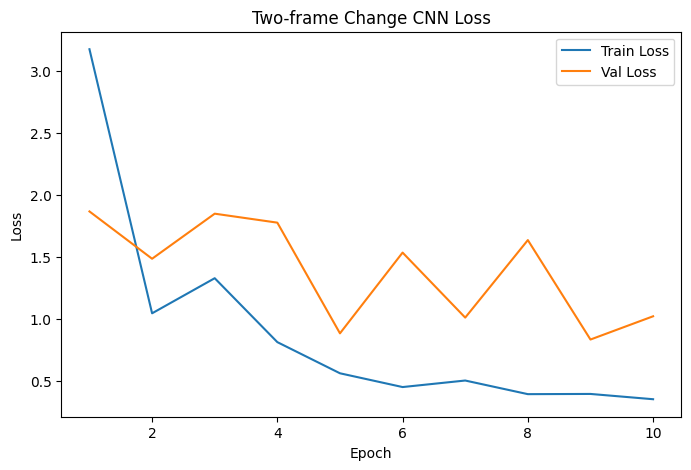

In [18]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], label="Train Loss")
plt.plot(history_df["epoch"], history_df["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Two-frame Change CNN Loss")
plt.legend()
plt.show()

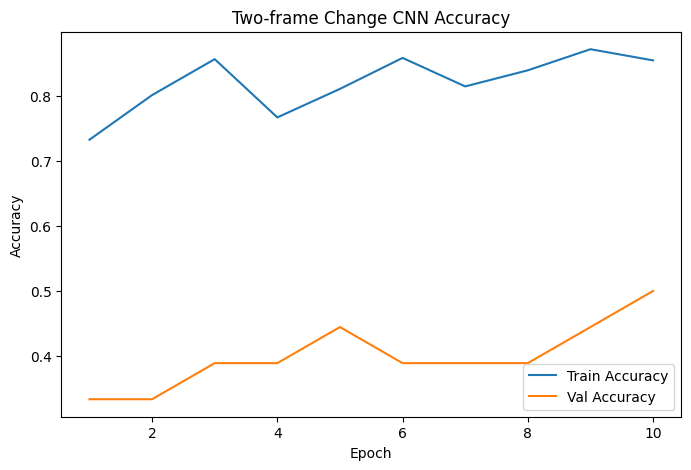

In [19]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_accuracy"], label="Train Accuracy")
plt.plot(history_df["epoch"], history_df["val_accuracy"], label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Two-frame Change CNN Accuracy")
plt.legend()
plt.show()

In [20]:
best_model = TwoFrameCNN(num_classes=2).to(device)
best_model.load_state_dict(torch.load(best_model_path, map_location=device))

test_metrics = evaluate(best_model, test_loader, criterion, device)

print("Test Results:")
print("Accuracy:", test_metrics["accuracy"])
print("Precision:", test_metrics["precision"])
print("Recall:", test_metrics["recall"])
print("F1:", test_metrics["f1"])
print("AUC:", test_metrics["auc"])
print("Confusion Matrix:")
print(test_metrics["confusion_matrix"])

100%|██████████| 4/4 [00:01<00:00,  2.58it/s]

Test Results:
Accuracy: 0.5901639344262295
Precision: 0.5151515151515151
Recall: 0.6538461538461539
F1: 0.576271186440678
AUC: 0.7032967032967034
Confusion Matrix:
[[19 16]
 [ 9 17]]


In [21]:
test_result_df = pd.DataFrame([{
    "model": "two_frame_change_cnn",
    "K": 2,
    "strategy": "early_late",
    "input_type": "stacked_6_channel",
    "test_accuracy": test_metrics["accuracy"],
    "test_precision": test_metrics["precision"],
    "test_recall": test_metrics["recall"],
    "test_f1": test_metrics["f1"],
    "test_auc": test_metrics["auc"]
}])

test_result_df.to_csv(
    RESULTS_DIR / "two_frame_change_cnn_test_results.csv",
    index=False
)

test_result_df

,model,K,strategy,input_type,test_accuracy,test_precision,test_recall,test_f1,test_auc
0,two_frame_change_cnn,2,early_late,stacked_6_channel,0.590164,0.515152,0.653846,0.576271,0.703297


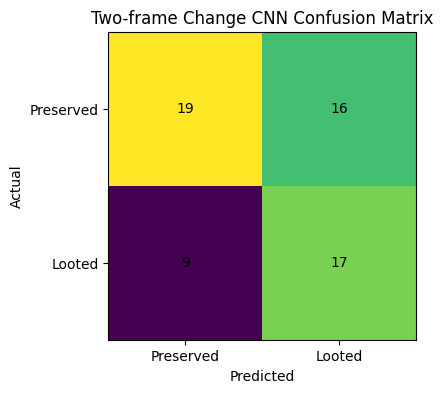

In [22]:
cm = test_metrics["confusion_matrix"]

plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.title("Two-frame Change CNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks([0, 1], ["Preserved", "Looted"])
plt.yticks([0, 1], ["Preserved", "Looted"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()